_Neural Data Science_

Lecturer: Dr. Jan Lause, Prof. Dr. Philipp Berens

Tutors: Jonas Beck, Fabio Seel, Julius Würzler

Summer term 2025

Student names: **Karim Zaghw, Kai Rothe, Mohammed Abbas Ansari**

LLM Disclaimer:  Yes, ChatGPT and Copilot was used in almost all the cell blocks to produce code. Modifications was done to LLM's output and care was taken to ensure desired outcome. 

# Coding Lab 6

In this exercise we are going to fit a latent variable model (Poisson GPFA) to both toy data and real data from monkey primary visual cortex. For details, see [Ecker et al. 2014](https://www.cell.com/neuron/pdf/S0896-6273(14)00104-4.pdf).

## Preliminaries

### 1. Code 

The toolbox we are going to use contains an implementation of the EM algorithm to fit the poisson-gpfa. 

Assuming you `git clone https://github.com/berenslab/poisson-gpfa` to the parent directory and have the following directory structure:


```
├── data/
│   └── nds_cl_6_data.mat
├── poisson-gpfa/
├── notebooks
│   └── CodingLab6.ipynb
├── matplotlib_style.txt
├── requirements.txt
```

then you can import the related functions via:

```
import sys
sys.path.append('../poisson-gpfa/')
sys.path.append('../poisson-gpfa/funs')

import funs.util as util
import funs.engine as engine
```

Change the paths if you have a different directory structure. For the details of the algorithm, please refer to the thesis `hooram_thesis.pdf` from ILIAS.

### 2. Data

Download the data file ```nds_cl_6_data.mat``` from ILIAS and save it in a ```data/``` folder.

In [ ]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

# style
import seaborn as sns

# poisson-gpfa
import sys

sys.path.append("../poisson-gpfa/")
sys.path.append("../poisson-gpfa/funs")

import funs.util as util
import funs.engine as engine

%matplotlib inline

%load_ext jupyter_black

%load_ext watermark
%watermark --time --date --timezone --updated --python --iversions --watermark -p sklearn

The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black
The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Last updated: 2025-06-01 20:21:58CEST

Python implementation: CPython
Python version       : 3.10.0
IPython version      : 8.35.0

sklearn: 1.6.1

seaborn   : 0.13.2
matplotlib: 3.10.1
sys       : 3.10.0 | packaged by conda-forge | (default, Nov 20 2021, 02:27:15) [Clang 11.1.0 ]
numpy     : 1.24.4
scipy     : 1.8.1
ipykernel : 6.29.5
debugpy   : 1.8.14

Watermark: 2.5.0



In [206]:
plt.style.use("../matplotlib_style.txt")

## Task 1. Generate some toy data to test the poisson-GPFA code

We start by verifying our code on toy data. The cell below contains code to generate data for 30 neurons, 100 trials (1000 ms each) and 50ms bin size. The neurons' firing rate $\lambda_k$ is assumed to be a constant $d_k$ modulated by a one-dimensional latent state $x$, which is drawn from a Gaussian process:

$\lambda_k = \exp(c_kx + d_k)$

Each neuron's weight $c_k$ is drawn randomly from a normal distribution and spike counts are sampled form a Poisson distribution with rate $\lambda_k$.

Your task is to fit a Poisson GPFA model with one latent variable to this data (see `engine.PPGPFAfit`).

Hint: You can use `util.dataset?`, `engine.PPGPFAfit?` or `util.initializeParams?` to find out more about the provided package.

*Grading: 3 pts*

In [207]:
# ---------------------------------
# simulate a training set (0.5 pts)
# ---------------------------------

# Initialize random number generator
np.random.seed(123)

# Specify dataset & fitting parameters
xdim = 1
ydim = 30
numTrials = 100
trialDur = 1000
binSize = 50
dOffset = 1.0

# Sample from the model (make a toy dataset)
training_set = util.dataset(
    seed=np.random.randint(1e6),
    xdim=xdim,
    ydim=ydim,
    numTrials=numTrials,
    trialDur=trialDur,
    binSize=binSize,
    dOffset=dOffset,
    fixTau=True,
    fixedTau=np.array([0.1]),
    drawSameX=True,
)

+------------- Simulated Dataset Options -------------+
                                                    1 | Dimensionality of Latent State
                                                   30 | Dimensionality of Observed State (# neurons)
                                                 1000 | Duration of trials (ms):
                                                   50 | Size of bins (ms):
                                                  100 | Number of Trials
+-----------------------------------------------------+
Sampling trial 100 ...
Average firing rate per neuron in this dataset: 23.219 Hz.


### Fit the model

In [208]:
# -----------------------
# fit the model (0.5 pts)
# -----------------------

# Initialize parameters using Poisson-PCA
initParams = util.initializeParams(xdim, ydim, training_set)

# choose sensible parameters and run fit
fitToy = engine.PPGPFAfit(
    experiment=training_set,
    initParams=initParams,
    inferenceMethod="laplace",
    EMmode="Batch",
    maxEMiter=50,
)

Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    1 | Dimensionality of Latent State
                                                   30 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                   50 | Max EM iterations:
                                              laplace | Inference Method
+-----------------------------------------------------+
Iteration:  50 of  50, nPLL: = -427.4458
This dataset is a simulated dataset.
Processing performance against ground truth parameters...


In [209]:
# some useful functions
def allTrialsState(fit: engine.PPGPFAfit, p) -> np.ndarray:
    """Reshape the latent signal and the spike counts"""
    x = np.zeros([p, 0])
    for i in range(len(fit.infRes["post_mean"])):
        x = np.concatenate((x, fit.infRes["post_mean"][i]), axis=1)
    return x


def allTrialsX(training_set: util.dataset) -> np.ndarray:
    """Reshape the ground truth
    latent signal and the spike counts"""
    x_gt = np.array([])
    for i in range(len(training_set.data)):
        x_gt = np.concatenate((x_gt, training_set.data[i]["X"][0]), axis=0)
    return x_gt

### Plot the ground truth vs. inferred model
Verify your fit by plotting both ground truth and inferred parameters for:
1. weights C
2. biases d
3. latent state x 

Note that the sign of fitted latent state and its weights are ambiguous (you can flip both without changing the model). Make sure you correct the sign for the plot if it does not match the ground truth.

In [210]:
# All trials latent state vector
x_est = allTrialsState(fitToy, 1).flatten()
x_true = allTrialsX(training_set)

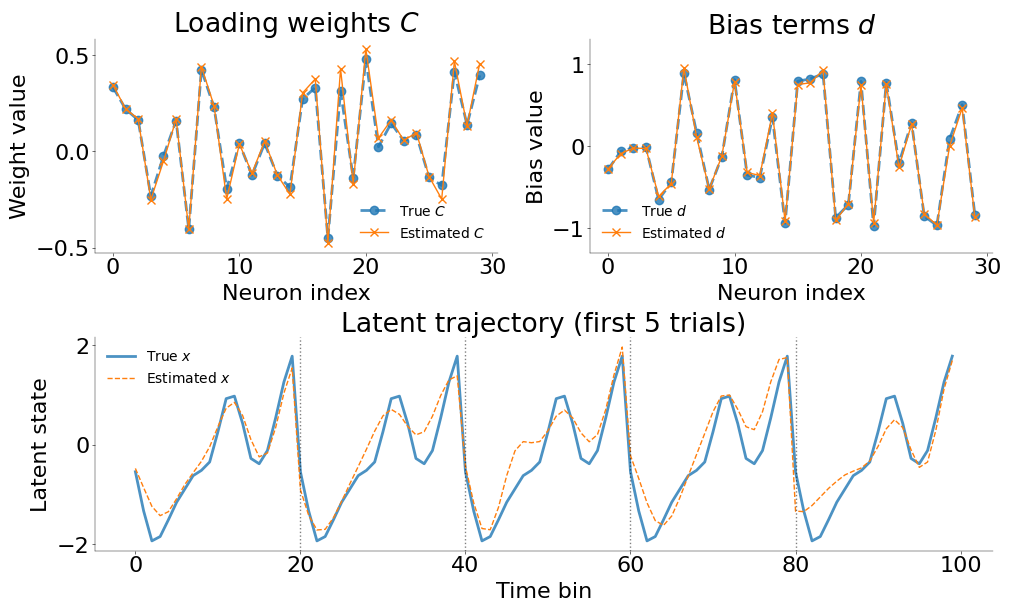

In [211]:
# ------------------------------------------------------
# Plot ground truth vs. inferred model
# Plot the weights `C`, biases `d` and latent states (2 pts)
# ------------------------------------------------------

# add plot
fig, ax = plt.subplot_mosaic([["C", "d"], ["latent", "latent"]], figsize=(10, 6))
# For d & C consider also plotting the optimal weights as a dotted line for reference

# For the latent states consider seperating each trial by a vertical line
# plot only for a subset of trials

# Extract true and estimated parameters
true_C = training_set.params["C"].flatten()
est_C = fitToy.optimParams["C"].flatten()
true_d = training_set.params["d"]
est_d = fitToy.optimParams["d"]

# Plot weights C
ax["C"].plot(true_C, "o--", label="True $C$", lw=2, alpha=0.8)
ax["C"].plot(est_C, "x-", label="Estimated $C$")
ax["C"].set_title("Loading weights $C$")
ax["C"].set_xlabel("Neuron index")
ax["C"].set_ylabel("Weight value")
ax["C"].legend()

# Plot biases d
ax["d"].plot(true_d, "o--", label="True $d$", lw=2, alpha=0.8)
ax["d"].plot(est_d, "x-", label="Estimated $d$")
ax["d"].set_title("Bias terms $d$")
ax["d"].set_xlabel("Neuron index")
ax["d"].set_ylabel("Bias value")
ax["d"].set_ylim(-1.3, 1.3)
ax["d"].legend(loc="lower left")

# Plot latent states for a subset of trials
bins_per_trial = training_set.T
num_plot_trials = 5  # plot first 5 trials
n_pts = num_plot_trials * bins_per_trial
time = np.arange(n_pts)

ax["latent"].plot(time, x_true[:n_pts], label="True $x$", linewidth=2, alpha=0.8)
ax["latent"].plot(time, x_est[:n_pts], label="Estimated $x$", linestyle="--")
# draw vertical lines to separate trials
for t in range(1, num_plot_trials):
    ax["latent"].axvline(t * bins_per_trial, color="k", linestyle=":", alpha=0.5)
ax["latent"].set_title(f"Latent trajectory (first {num_plot_trials} trials)")
ax["latent"].set_xlabel("Time bin")
ax["latent"].set_ylabel("Latent state")
ax["latent"].legend(loc="upper left")

plt.show()

## Task 2: Fit GPFA model to real data. 

We now fit the model to real data and cross-validate over the dimensionality of the latent variable.

*Grading: 4 pts*



### Load data

The cell below implements loading the data and encapsulates it into a class that matches the interface of the Poisson GPFA engine. You don't need to do anything here.

In [212]:
class EckerDataset:
    """Loosy class"""

    def __init__(
        self,
        path: str,
        subject_id: int = 0,
        ydim: int = 55,
        trialDur: int = 2000,
        binSize: int = 100,
        numTrials: int = 100,
        ydimData: bool = False,
        numTrData: bool = True,
    ):
        # T = binSize #int(trialDur/binSize)
        T = int(trialDur / binSize)
        matdat = sio.loadmat(path)
        self.matdat = matdat
        data = []
        trial_durs = []
        for trial_id in range(numTrials):
            trial_time = matdat["spikeTimes"][:, trial_id][0]
            trial_big_time = np.min(trial_time)
            trial_end_time = np.max(trial_time)
            trial_durs.append(trial_end_time - trial_big_time)
        for trial_id in range(numTrials):
            data.append(
                {
                    "Y": matdat["spikeCounts"][:, :, trial_id],
                    "spike_time": matdat["spikeTimes"][:, trial_id],
                }
            )
        self.T = T
        self.trial_durs = trial_durs
        self.data = data
        self.trialDur = trialDur
        self.binSize = binSize
        self.numTrials = numTrials
        self.ydim = ydim
        util.dataset.getMeanAndVariance(self)
        util.dataset.getAvgFiringRate(self)
        util.dataset.getAllRaster(self)

In [213]:
path = "../data/nds_cl_6_data.mat"
data = EckerDataset(path)

### Fit Poisson GPFA models and perform model comparison

Split the data into 80 trials used for training and 20 trials held out for performing model comparison. On the training set, fit models using one to five latent variables. Compute the performance of each model on the held-out test set.

Hint: You can use the `crossValidation` function in the Poisson GPFA package.

Optional: The `crossValidation` function computes the sum of the squared errors (SSE) on the test set, which is not ideal. The predictive log-likelihood under the Poisson model would be a better measure, which you are welcome to compute instead.

### Derivation for log-likelihood

_You can add your calculations in_ $\LaTeX$ _here_.

$p_\lambda(x_t) = \ldots$

$L(\lambda_k; x_1, ..., x_N) = \ldots$ 

$log(L) = l(\lambda_k; x_1, ..., x_N) = \ldots$

In [214]:
# ------------------------------
# Perfom cross validation (1 pt)
# ------------------------------

# Set up cross‐validation parameters
num_train = 80
num_test = 20
max_xdim = 5
max_em_iter = 50

np.random.seed(0)  # for reproducibility

# do the actual cross validation
xval = util.crossValidation(
    experiment=data,
    numTrainingTrials=num_train,
    numTestTrials=num_test,
    maxXdim=max_xdim,
    maxEMiter=max_em_iter,
    inferenceMethod="laplace",
    learningMethod="batch",
)

Assessing optimal latent dimensionality will take a long time.
Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    1 | Dimensionality of Latent State
                                                   55 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                   50 | Max EM iterations:
                                              laplace | Inference Method
+-----------------------------------------------------+
Iteration:  50 of  50, nPLL: = -388.8255Performing leave-one-out cross validation...
Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    2 | Dimensionality of Latent State
                                                   55 | Dimensionality of Observed State (# neurons)
         

Optimal latent dimensionality: 5


/Users/kairothe/Documents/Projects/Neural Data Science/GitRepo/notebooks/../poisson-gpfa/funs/util.py:261: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


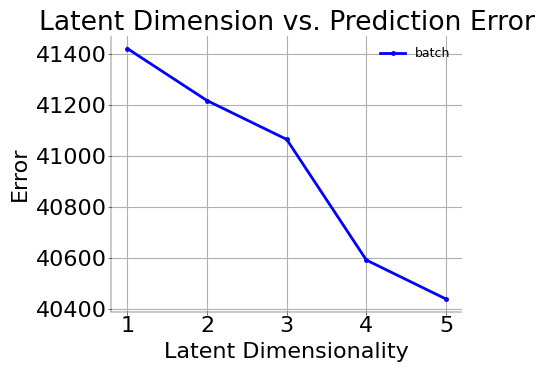

In [215]:
print(f"Optimal latent dimensionality: {xval.optimXdim}")

xval.method = (
    xval.learningMethod
)  # Added because xval.plotPredictionError() throws an error otherwise
xval.plotPredictionError()

### Plot the test error

Make a plot of the test error for the five different models. As a baseline, please also include the test error of a model without a latent variable. This is essentially the SSE of a constant rate model (or Poisson likelihood if you did the optional part above). Note: We assume a constant firing rate across trials, but not necessarily across time.

In [216]:
# --------------------------------------------------------------------------------
# Compute the test errors for the different latent variable models (1 pt)
# --------------------------------------------------------------------------------

train_set, test_set = util.splitTrainingTestDataset(
    data, numTrainingTrials=80, numTestTrials=20
)
# compute baseline error
Y_train = np.stack([trial["Y"] for trial in train_set.data], axis=2)
mean_rate_time = np.mean(Y_train, axis=2)

baseline_error = 0.0
for trial in test_set.data:
    baseline_error += np.sum((trial["Y"] - mean_rate_time) ** 2)

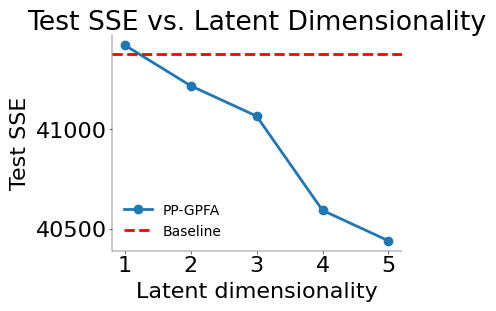

In [222]:
# -------------------------------------------------------------------------
# Plot the test errors for the different latent variable models
# and answer the questions below (1+1 pts)
# -------------------------------------------------------------------------

# Your plot here
fig, ax = plt.subplots(figsize=(4, 3))

# plot model error
xdims = np.arange(1, len(xval.errs) + 1)
ax.plot(xdims, xval.errs, "o-", label="PP-GPFA", lw=2)

# plot baseline
ax.axhline(baseline_error, linestyle="--", color="red", lw=2, label="Baseline")

ax.set_xlabel("Latent dimensionality")
ax.set_ylabel("Test SSE")
ax.set_title("Test SSE vs. Latent Dimensionality")
ax.set_xticks(xdims)
ax.legend(loc="lower left")
plt.show()

### Questions

**Is the baseline error (0 latents) about what you expect in relation to the other models? Why or why not?**

It makes sense that a flat, constant‐rate model (no latents) sits in the same ballpark as our 1‐ and 2‐dimensional PP-GPFA fits. But for another random seet settings (even for higher maximal iterations up to 200) we observed that the 3-latent fit actually performs worse than the baseline. However, this is what we'd expect any time we
- run EM on a non‐convex objective that can get stuck and local minima
- give the model more parameters than our 80 trials can firmly constrain
- evaluate on just a single train/test split

In contrast, the constant‐rate baseline is deterministic and can’t over‐fit or suffer from EM getting stuck in local minima—so it sometimes beats a poorly converged latent model.

**Can you identify a "best model". If so, which is it and what does this say about the structure of the latent state?**

On this single 80/20 split, the 5-dimensional GPFA achieves the lowest held-out SSE, followed by the 4-dimensional fit. That suggests our population really does harbor several independent shared fluctuations, at least up to five dimensions. However, because the curve is noisy (sensible to random initializations) we’d recommend either
- re-running each EM fit from multiple random starts, or
- doing a true k-fold cross-validation to get more consistent results

## Task 3. Visualization: population rasters and latent state.
Use the model with a single latent state. 

Create a raster plot where you show for each trial the spikes of all neurons as well as the trajectory of the latent state `x` (take care of the correct time axis). Sort the neurons by their weights `c_k`. Plot only the first 20 trials.

*Grading: 2 pts*

Max spike count: 28


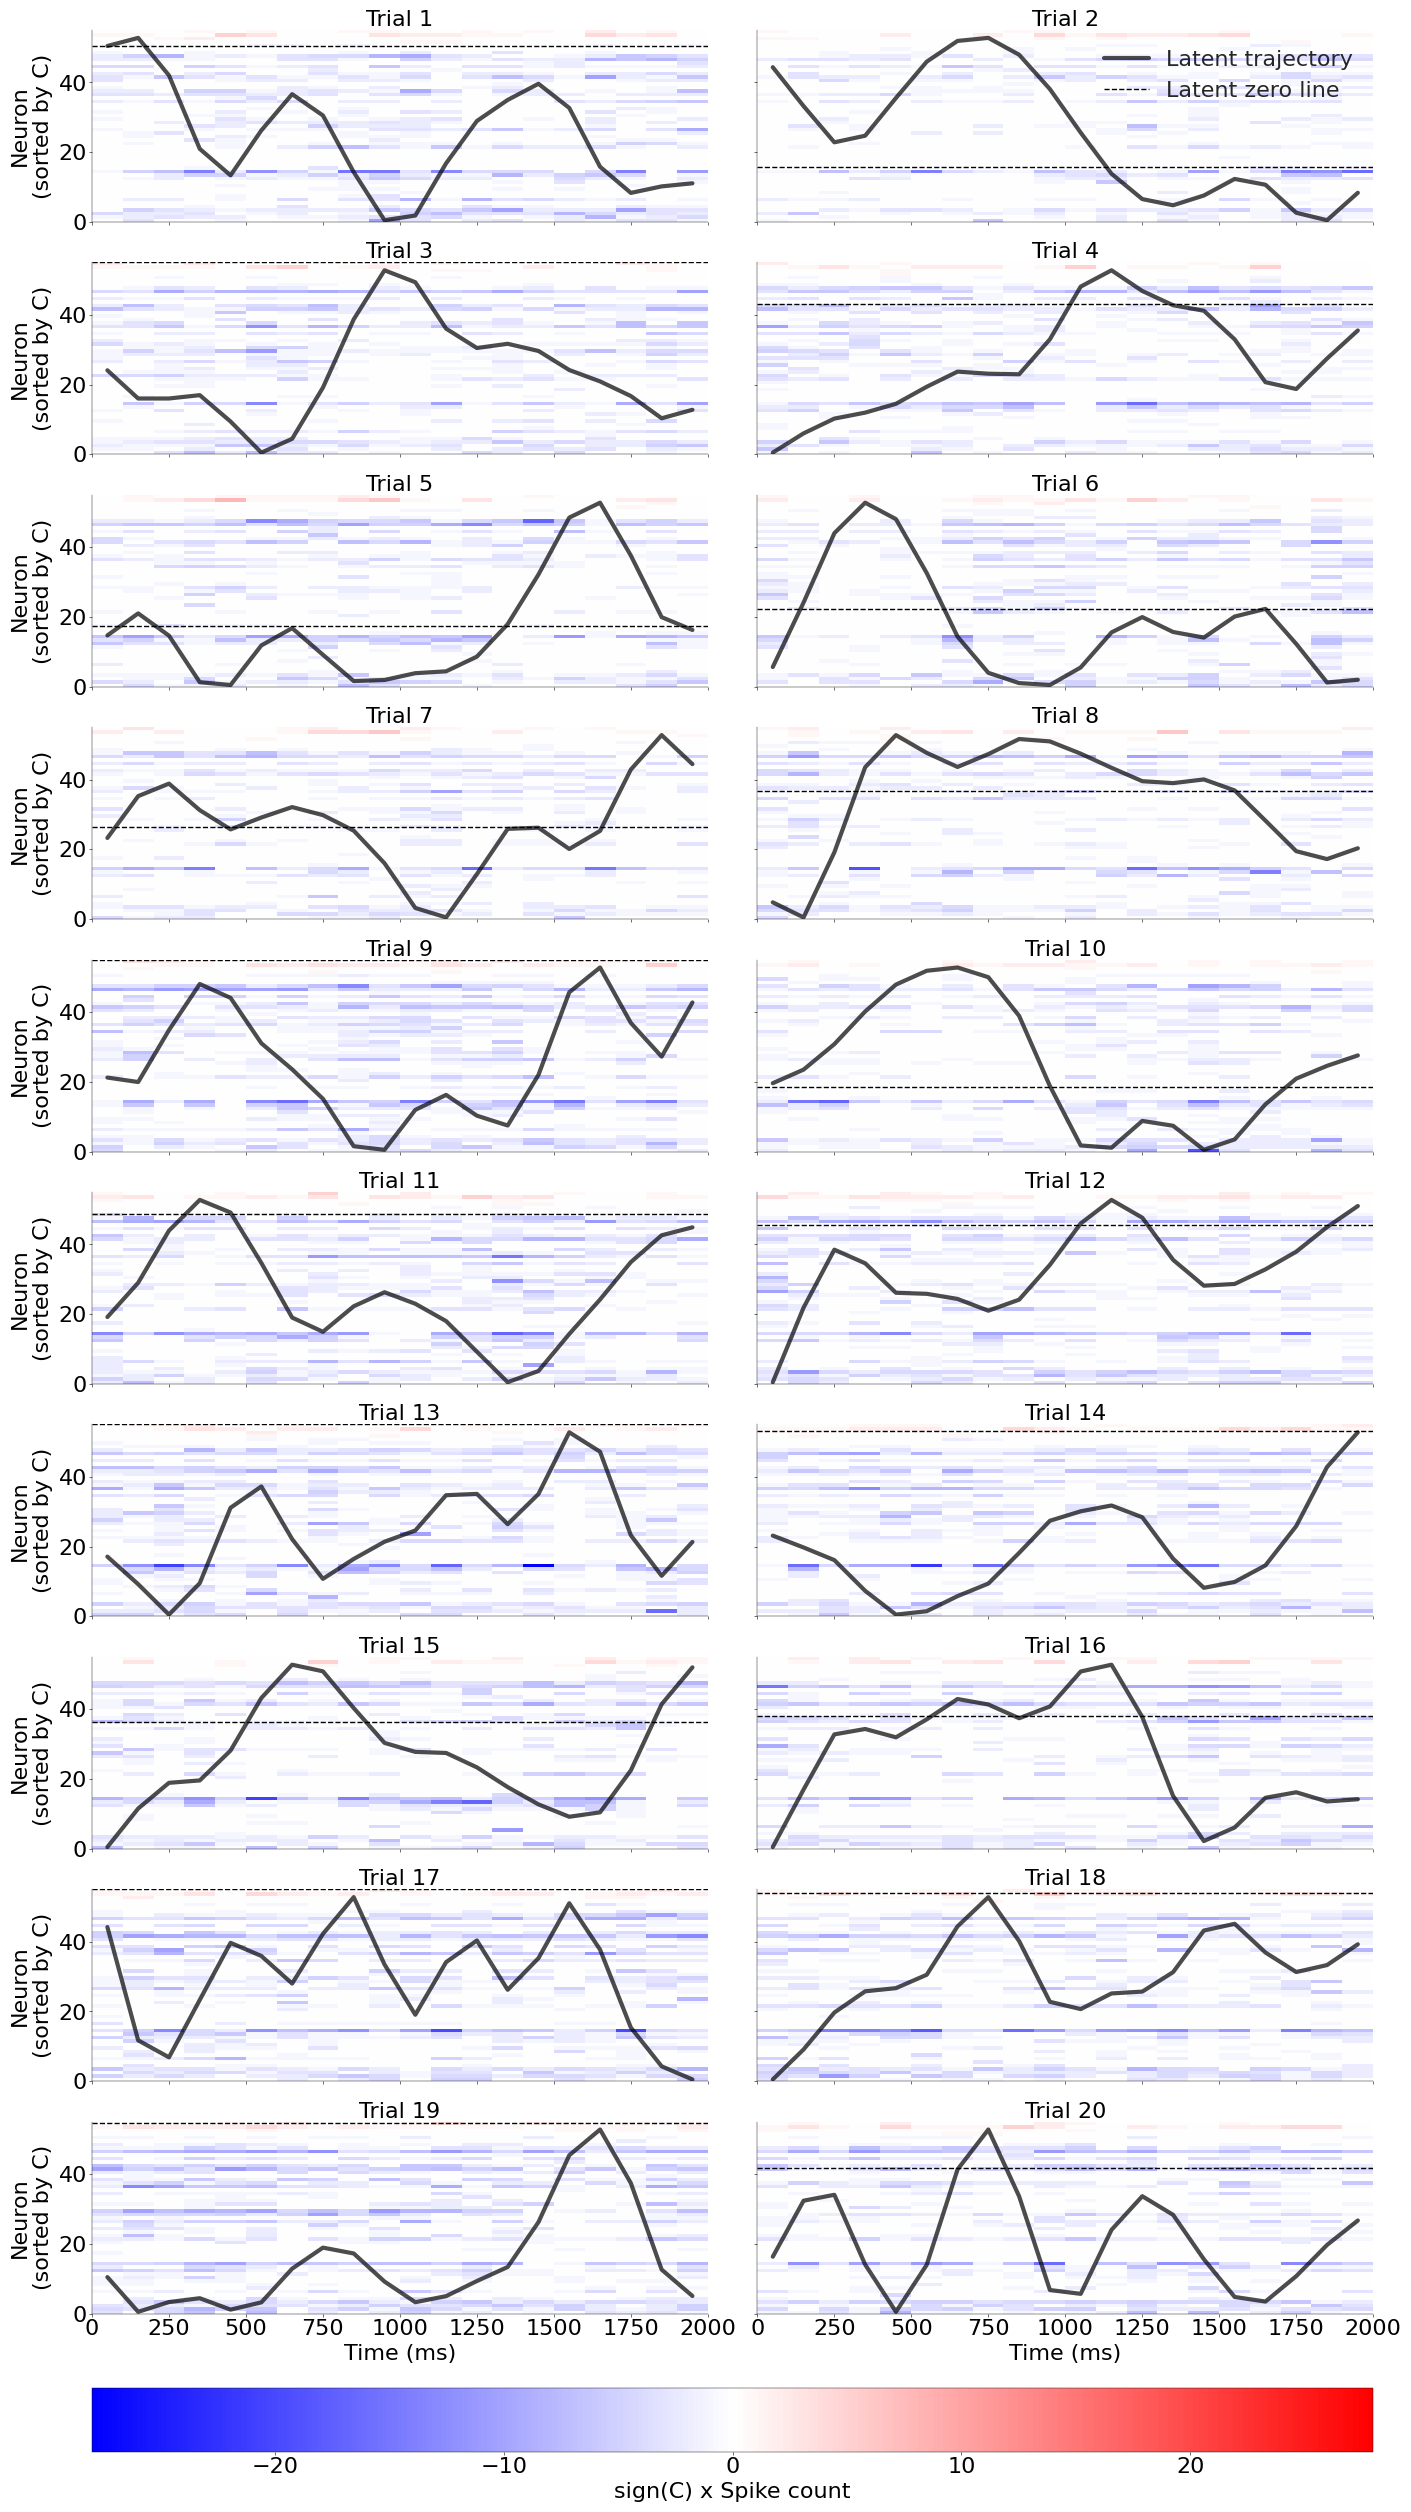

In [218]:
# Your plot here

plt.rcParams.update({"font.size": 16})

fig, axs = plt.subplots(
    10, 2, figsize=(14, 25), sharey=True, sharex=True, constrained_layout=True
)

ts = np.linspace(0, 2000, 100)
xa = 0.15
xs = 0.7 * xa * np.sin(ts / 1000 * 3.4 * 2 * np.pi) + xa

# sort neurons by weight (constant across trials)
evaluated_model = xval.fits[0]  # choose first model, the one with one latent variable
weights = evaluated_model.optimParams["C"]  # neurons x latent variables
sorted_idx = np.argsort(
    weights[:, 0]  # take first column == only one since only one latent variable
)
sorted_weights = weights[sorted_idx, 0]  # sorted weights for first latent variable

max_spike_count = 0
with sns.axes_style("ticks"):
    for ntrial, ax in enumerate(axs.flat):
        if ntrial >= 20:
            break

        ax.set_title(f"Trial {ntrial + 1}", fontsize=16)

        x = np.arange(50, 2000, 100)  # assume binsize of 100ms

        # --------------------------------------------------------
        # plot the raster for each neuron and latent state (2 pts)
        # --------------------------------------------------------

        # hint: can be plotted on top of the corresponding raster

        # Sort neurons by the first latent variable weight

        # Get spike counts for this trial and plot neurons in sorted order
        binned_spike_times = data.data[ntrial]["Y"]
        if np.max(binned_spike_times) > max_spike_count:
            max_spike_count = np.max(binned_spike_times)
        im = ax.imshow(
            binned_spike_times * np.sign(sorted_weights[:, np.newaxis]),
            cmap="bwr",
            aspect="auto",
            origin="lower",
            interpolation="none",
            vmin=-28,
            vmax=28,
            extent=[x[0] - 50, x[-1] + 50, 0, data.ydim],
        )

        # Plot latent state and zero line
        latent_x = evaluated_model.infRes["post_mean"][ntrial].flatten()
        latent_scaled = (latent_x - np.min(latent_x)) / (
            np.max(latent_x) - np.min(latent_x)
        ) * data.ydim * 0.95 + 0.5  # Scale latent state to fit on plot
        ax.plot(
            x,
            latent_scaled,
            "k-",
            lw=3,
            alpha=0.7,
            label="Latent trajectory",
        )

        zero_line_latent = (
            -np.min(latent_x) / (np.max(latent_x) - np.min(latent_x)) * data.ydim
        )
        ax.hlines(
            min(zero_line_latent, data.ydim),
            colors="k",
            linestyles="dashed",
            xmin=0,
            xmax=2000,
            lw=1,
            label="Latent zero line",
        )

        if ntrial == 1:
            ax.legend(loc="upper right", fontsize=16)
        if ntrial % 2 == 0:
            ax.set_ylabel("Neuron\n(sorted by C)")
        if ntrial == 18 or ntrial == 19:
            ax.set_xlabel("Time (ms)")


cbar = fig.colorbar(
    im, ax=axs, orientation="horizontal", location="bottom", fraction=0.03, pad=0.01
)
cbar.set_label("sign(C) x Spike count")

print("Max spike count:", max_spike_count)

By plotting both the sign of the weights C and the zero line of the latent trajectory, we can test our expectations for a good model: for neurons with negative weights (plotted blue), a positive (negative) latent state should correlate with lower (higher) firing rates (respectively), while for neurons with positive weights (plotted red), a positive (negative) latent state should correlate with higher (lower) firing rates (respectively). Most neurons are negatively weighted. Then we can observe this e.g. in trial 19 after 1.5s and 2s, the latent trajectory increases from a negative value to 0, and the negatively weighted (blue colored) neurons fire less compared to the resyt of the trial. Similar observations can be made for other trials, e.g. trial 6, 10 and 16, intuiviely where there is less blue below the latent trajectory, and more blue above (because the neurons where sorted by their weights).

## Task 4. Visualization of covariance matrix.

Plot (a) the covariance matrix of the observed data as well as its approximation using (b) one and (c) five latent variable(s). Use the analytical solution for the covariance matrix of the approximation*. Note that the solution is essentially the mean and covariance of the [log-normal distribution](https://en.wikipedia.org/wiki/Log-normal_distribution).

$ \mu = \exp(\frac{1}{2} \text{ diag}(CC^T)+d)$

$ \text{Cov}= \mu\otimes\mu^T \odot \exp(CC^T)+\mu\cdot \mathbb{I} - \mu\otimes\mu^T$ 

*[Krumin, M., and Shoham, S. (2009). Generation of Spike Trains with Controlled Auto- and Cross-Correlation Functions. Neural Computation 21, 1642–1664](http://www.mitpressjournals.org/doi/10.1162/neco.2009.08-08-847).

*Grading: 3 pts*

In [219]:
# --------------------------------------------------------------
# Complete the analytical solution for the covariance matrix of
# the approximation using the provide equations (2 pts)
# --------------------------------------------------------------


def cov(fit: engine.PPGPFAfit) -> np.ndarray:
    C = fit.optimParams["C"]
    d = fit.optimParams["d"]
    mu = np.exp(1 / 2 * np.diag(C @ C.T) + d)
    Cov = np.outer(mu, mu.T) * np.exp(C @ C.T) + np.diag(mu) - np.outer(mu, mu.T)
    return Cov, mu


# --------------------------------------------------------------
# Plot the covariance matrix of
# (1) the observed data
# (2) its approximation using 1 latent variable
# (3) its approximation using 5 latent variable
# and explain how they compare (1+1 pts).
# --------------------------------------------------------------

obs_corr = np.cov(data.all_raster)
opt_r1, mu1 = cov(xval.fits[0])
opt_r5, mu5 = cov(xval.fits[4])

# HINT: Think about which type of colormap and ranges are appropriate here.


def plot_cov_or_corr(plot_corr=False, obs_corr=obs_corr, opt_r1=opt_r1, opt_r5=opt_r5):
    fig, axs = plt.subplots(
        1, 3, figsize=(10, 3.5), sharey=True, constrained_layout=True
    )
    # add plot to visualize the differences in the covariance matrices

    if plot_corr:
        fig.suptitle("Correlation matrices of data vs. model approximations")
    else:
        fig.suptitle("Covariance matrices of data vs. model approximations")
        max_cov_element = 0

    for ax, Cov, title in zip(
        axs,
        [obs_corr, opt_r1, opt_r5],
        ["Ground truth", "1 latent variable", "5 latent variables"],
    ):
        if not plot_corr:
            plot_matrix = Cov
            vmin, vmax = -21, 21
            if np.max(np.abs(Cov)) > max_cov_element:
                max_cov_element = np.max(np.abs(Cov))
        else:
            plot_matrix = Cov / np.sqrt(np.outer(np.diag(Cov), np.diag(Cov)))
            vmin, vmax = -1, 1

        im = ax.imshow(
            plot_matrix,
            cmap="bwr",
            vmin=vmin,
            vmax=vmax,
            aspect="auto",
            origin="lower",
        )
        ax.set_title(title, fontsize=14)
        ax.set_xlabel("Neuron")
        ax.set_ylabel("Neuron")

        if ax is axs[-1]:
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    if not plot_corr:
        print(f"Maximum absolute covariance element: {max_cov_element:.2f}")

    return fig, axs

Maximum absolute covariance element: 20.68


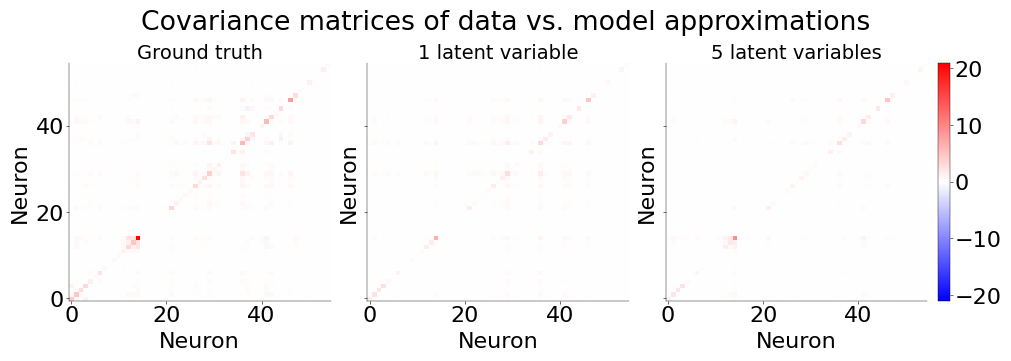

In [220]:
plot_cov_or_corr(plot_corr=False, obs_corr=obs_corr, opt_r1=opt_r1, opt_r5=opt_r5)
plt.show()

We find absolute covariances up to 20, especially it seems that there is one neuron, around index 15, with very large variance in the data, which makes it challenging to display the covariances informatively. Thus choose to also look at the correlation matrices (another option would be to use (symmetrical) log colorbar scale, but if overall correlations are low, the linear threshold (for small, close to zero values) setting is in our experience bit more involved than just looking at the correlation matrices).

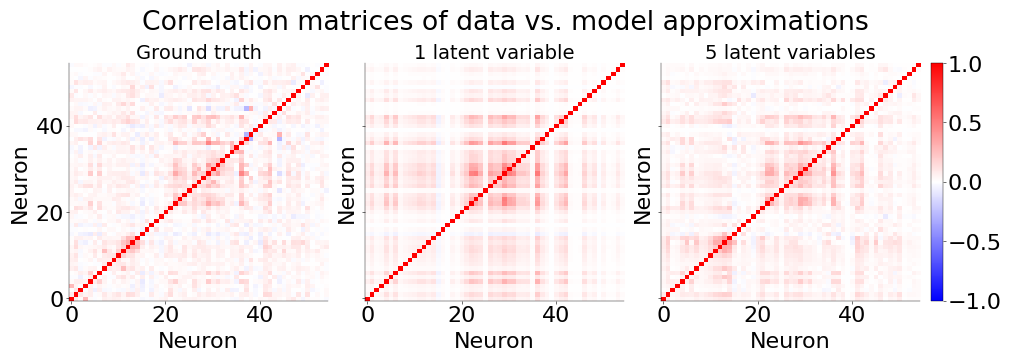

In [221]:
plot_cov_or_corr(plot_corr=True, obs_corr=obs_corr, opt_r1=opt_r1, opt_r5=opt_r5)
plt.show()

### Questions

What do you see / expect to see?

Ground truth: In the data we expect higher covariance between equal neurons than different neurons, which is confirmed by the observable diagoals in the covariance plot. Both models capture the variance of the highest varying neurons well. On the correlation plot, of course correlations between equal neurons are 1. We also observe only sparsly negatively correlated neurons. 

Models: based on our previous evaluation, we expect a better fit for more expressive models, i.e. bigger latent dimension. On top, with only one latent variable, the correlation structure must be simpler (it's only not all correlated due to different weights between neurons), as we can see in the above approximation of Cov (add multiple, nearly 1-rank matrices). Indeed, while the 1 latent variable model already captures one of the dominant positive cross-correlation structures (red square from neuron 20 - 40), it doesn't capture a dominant spot of cross-correlations around the previously observed highly varying neuron around index 15, finer structures and negative correlations (mostly red). The correlation matrix for the 1 dimensional latent model indeed looks in comparison to the 5 dimensional model like a lower-rank approximation of the ground truth correlation. 